In [1]:
"""
CIF to PDF Utility

This notebook:
1. Validates existing calculated PDFs for unreasonable G(r) values
2. Identifies problematic CIF files by name
3. Can recalculate PDFs from CIF files if needed
"""
import sys
from pathlib import Path

# Add parent directory to path for config import
sys.path.insert(0, str(Path.cwd().parent))
from config import get_path

from diffpy.Structure import loadStructure
from diffpy.srreal.pdfcalculator import DebyePDFCalculator, PDFCalculator
from pyobjcryst import loadCrystal
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# Define paths using config
cif_dir = get_path("csd_cifs")
pdf_dir = get_path("csd_calculated_pdfs")

print(f"CIF files: {cif_dir}")
print(f"Calculated PDFs: {pdf_dir}")

# List files
cif_files = sorted(cif_dir.glob("*.cif"))
pdf_files = sorted(pdf_dir.glob("*.dat"))

print(f"\nFound {len(cif_files)} CIF files")
print(f"Found {len(pdf_files)} PDF files")

CIF files: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/csd_structures/cifs
Calculated PDFs: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/csd_structures/calculated_pdfs

Found 701 CIF files
Found 700 PDF files


In [3]:
# ============================================================================
# VALIDATE EXISTING PDFs - Check for unreasonable G(r) values
# ============================================================================

# Define threshold for "unreasonable" G(r) - values beyond physical limits
G_MAX_THRESHOLD = 100  # Typical G(r) values should be well below this

problematic_files = []
valid_files = []
max_values = {}

print("Scanning PDFs for unreasonable G(r) values...")
print(f"Threshold: |G(r)| > {G_MAX_THRESHOLD}\n")

for pdf_file in pdf_files:
    try:
        data = np.loadtxt(pdf_file, skiprows=1)  # Skip header
        r = data[:, 0]
        g = data[:, 1]
        
        max_g = np.max(np.abs(g))
        max_values[pdf_file.name] = max_g
        
        if max_g > G_MAX_THRESHOLD:
            problematic_files.append((pdf_file.name, max_g))
        else:
            valid_files.append(pdf_file.name)
            
    except Exception as e:
        print(f"Error reading {pdf_file.name}: {e}")
        problematic_files.append((pdf_file.name, "READ_ERROR"))

print(f"Valid PDFs: {len(valid_files)}")
print(f"Problematic PDFs: {len(problematic_files)}")

Scanning PDFs for unreasonable G(r) values...
Threshold: |G(r)| > 100

Valid PDFs: 636
Problematic PDFs: 64


In [ ]:
# ============================================================================
# DISPLAY PROBLEMATIC FILES
# ============================================================================

if problematic_files:
    print("=" * 70)
    print("PROBLEMATIC FILES - Unreasonable G(r) values detected")
    print("=" * 70)
    
    # Sort by max G(r) value (descending)
    problematic_sorted = sorted(
        [p for p in problematic_files if isinstance(p[1], (int, float))],
        key=lambda x: x[1], 
        reverse=True
    )
    
    print(f"\n{'Filename':<40} {'Max |G(r)|':>15}")
    print("-" * 55)
    for filename, max_g in problematic_sorted:
        print(f"{filename:<40} {max_g:>15.1f}")
    
    # Extract CIF names for exclusion
    problematic_cif_names = [f.replace('.dat', '.cif') for f, _ in problematic_files if isinstance(_, (int, float))]
    print(f"\n\nCorresponding CIF files to exclude ({len(problematic_cif_names)} total):")
    print("-" * 55)
    for cif_name in problematic_cif_names:
        print(f"  {cif_name}")
else:
    print("All PDFs have reasonable G(r) values!")

PROBLEMATIC FILES - Unreasonable G(r) values detected

Filename                                      Max |G(r)|
-------------------------------------------------------
2_GAFORM11.dat                                    6473.5
2_ITAHEQ.dat                                      3350.4
p_LOSKUA.dat                                      3140.1
6_FEWQIJ.dat                                      2320.0
p_YURJUR.dat                                      2305.4
p_LOSLAH.dat                                      2007.2
p_LOJQUY.dat                                      1843.3
6_UFEXEJ.dat                                      1693.9
p_QEMMOL.dat                                      1463.3
6_IFESAP.dat                                      1125.5
p_LOSKUA01.dat                                    1052.6
1_ASIRAX.dat                                       901.7
4_CISVEH.dat                                       841.1
1_ASIREB.dat                                       831.8
1_CUWHUZ.dat                      

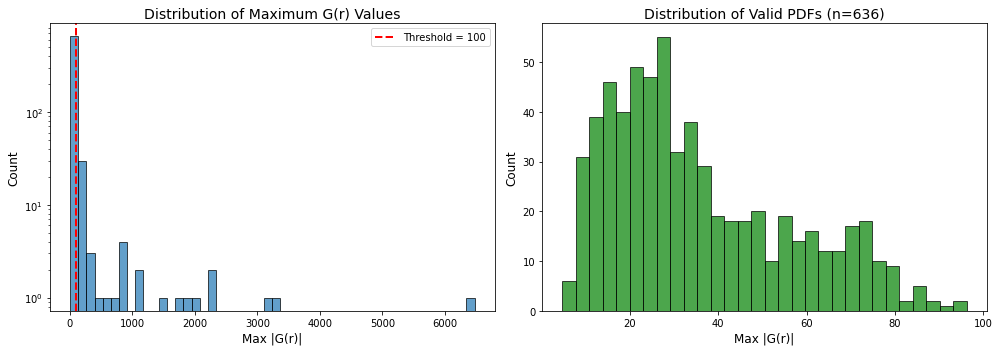


Statistics of max |G(r)| values:
  Min:    4.80
  Max:    6473.47
  Mean:   90.60
  Median: 32.79


In [5]:
# ============================================================================
# VISUALIZE G(r) DISTRIBUTION
# ============================================================================

# Plot histogram of max G(r) values
max_g_values = [v for v in max_values.values() if isinstance(v, (int, float))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all max values
ax1 = axes[0]
ax1.hist(max_g_values, bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(G_MAX_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold = {G_MAX_THRESHOLD}')
ax1.set_xlabel('Max |G(r)|', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Distribution of Maximum G(r) Values', fontsize=14)
ax1.legend()
ax1.set_yscale('log')

# Histogram zoomed to reasonable values
ax2 = axes[1]
reasonable_values = [v for v in max_g_values if v <= G_MAX_THRESHOLD]
ax2.hist(reasonable_values, bins=30, edgecolor='black', alpha=0.7, color='green')
ax2.set_xlabel('Max |G(r)|', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title(f'Distribution of Valid PDFs (n={len(reasonable_values)})', fontsize=14)

plt.tight_layout()
plt.show()

print(f"\nStatistics of max |G(r)| values:")
print(f"  Min:    {min(max_g_values):.2f}")
print(f"  Max:    {max(max_g_values):.2f}")
print(f"  Mean:   {np.mean(max_g_values):.2f}")
print(f"  Median: {np.median(max_g_values):.2f}")

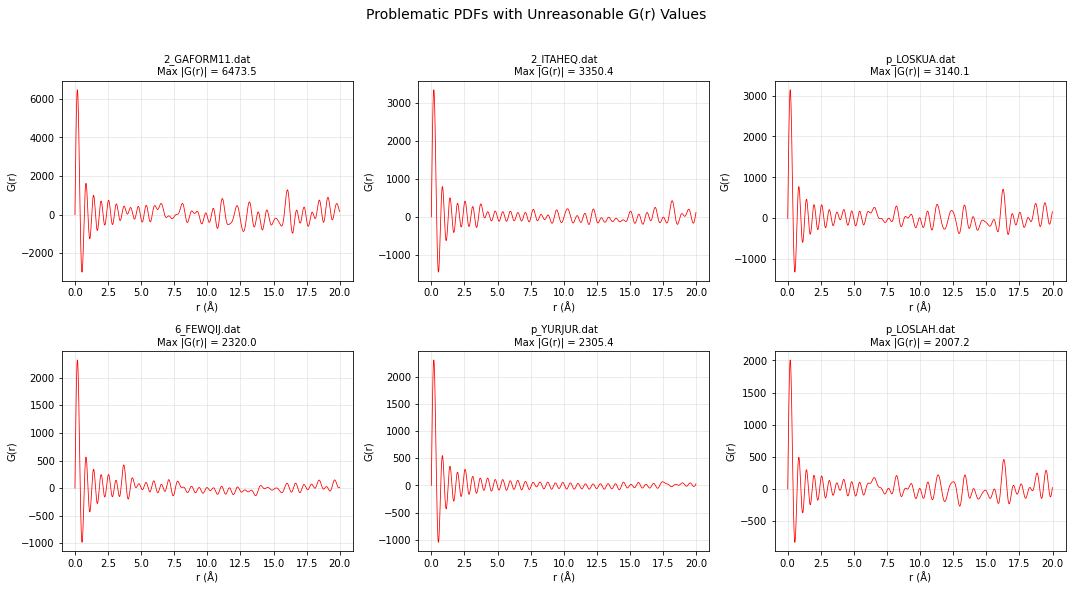

In [6]:
# ============================================================================
# PLOT PROBLEMATIC PDFs
# ============================================================================

if problematic_files:
    n_to_plot = min(6, len([p for p in problematic_files if isinstance(p[1], (int, float))]))
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    # Plot the worst offenders
    for idx, (filename, max_g) in enumerate(problematic_sorted[:n_to_plot]):
        pdf_path = pdf_dir / filename
        data = np.loadtxt(pdf_path, skiprows=1)
        r = data[:, 0]
        g = data[:, 1]
        
        axes[idx].plot(r, g, 'r-', linewidth=0.8)
        axes[idx].set_title(f"{filename}\nMax |G(r)| = {max_g:.1f}", fontsize=10)
        axes[idx].set_xlabel('r (Å)')
        axes[idx].set_ylabel('G(r)')
        axes[idx].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_to_plot, 6):
        axes[idx].set_visible(False)
    
    plt.suptitle("Problematic PDFs with Unreasonable G(r) Values", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

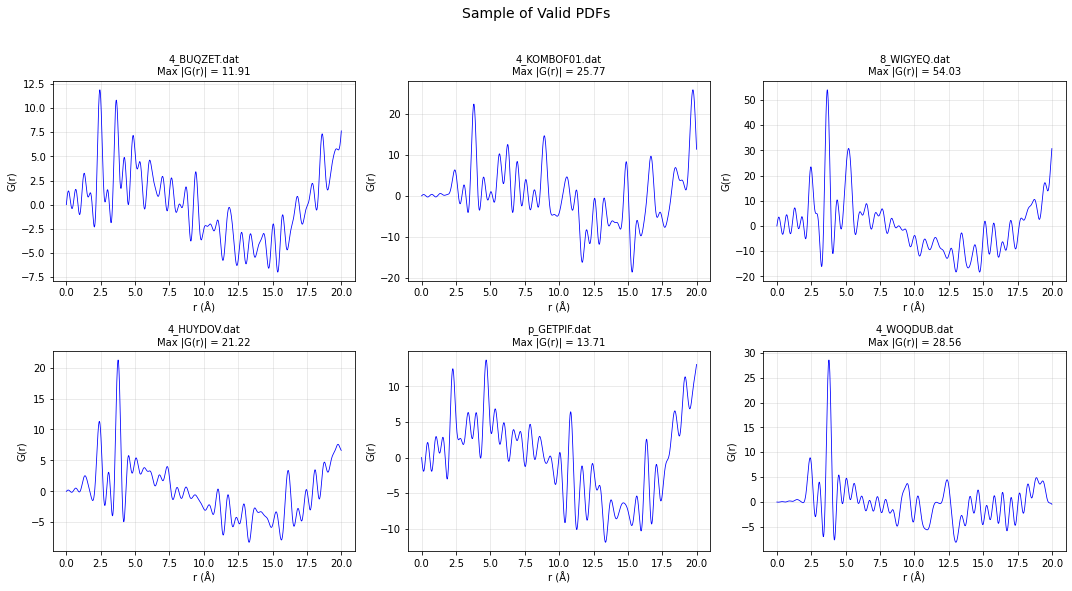

In [7]:
# ============================================================================
# PLOT VALID PDFs (sample)
# ============================================================================

# Show a sample of valid PDFs for comparison
n_sample = min(6, len(valid_files))
sample_valid = np.random.choice(valid_files, n_sample, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, filename in enumerate(sample_valid):
    pdf_path = pdf_dir / filename
    data = np.loadtxt(pdf_path, skiprows=1)
    r = data[:, 0]
    g = data[:, 1]
    
    axes[idx].plot(r, g, 'b-', linewidth=0.8)
    axes[idx].set_title(f"{filename}\nMax |G(r)| = {max_values[filename]:.2f}", fontsize=10)
    axes[idx].set_xlabel('r (Å)')
    axes[idx].set_ylabel('G(r)')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("Sample of Valid PDFs", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# SAVE EXCLUSION LIST
# ============================================================================

# Save list of problematic files for exclusion in training
if problematic_files:
    exclusion_list_path = get_path("labels") / "csd_excluded_cifs.txt"
    
    # Ensure directory exists
    exclusion_list_path.parent.mkdir(parents=True, exist_ok=True)
    
    with open(exclusion_list_path, 'w') as f:
        f.write("# CIF files excluded due to unreasonable G(r) values\n")
        f.write(f"# Threshold: |G(r)| > {G_MAX_THRESHOLD}\n")
        f.write(f"# Total excluded: {len(problematic_cif_names)}\n")
        f.write("#\n")
        for cif_name in problematic_cif_names:
            # Get corresponding max G(r) value
            dat_name = cif_name.replace('.cif', '.dat')
            max_g = max_values.get(dat_name, 'N/A')
            if isinstance(max_g, (int, float)):
                f.write(f"{cif_name}  # max|G(r)| = {max_g:.1f}\n")
            else:
                f.write(f"{cif_name}  # {max_g}\n")
    
    print(f"Exclusion list saved to: {exclusion_list_path}")
    print(f"  Contains {len(problematic_cif_names)} problematic CIF files")
else:
    print("No problematic files found - no exclusion list needed")

✓ Exclusion list saved to: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/labels/csd_excluded_cifs.txt
  Contains 64 problematic CIF files


In [ ]:
# ============================================================================
# OPTIONAL: Recalculate PDFs from CIF (if needed)
# ============================================================================

# This recalculates PDFs and ONLY saves those with reasonable G(r) values
# Problematic PDFs are skipped and logged

RECALCULATE = False  # Set to True to recalculate

if RECALCULATE:
    # Parameters matching the workflow
    QMAX = 11
    QMIN = 0.5
    RMAX = 20
    
    cif_files_to_process = list(cif_dir.glob("*.cif"))
    print(f"Processing {len(cif_files_to_process)} CIF files...")
    print(f"G(r) threshold: |G(r)| <= {G_MAX_THRESHOLD}\n")
    
    successful = 0
    skipped_unreasonable = []
    failed = []
    
    for cif_path in cif_files_to_process:
        try:
            model = loadCrystal(str(cif_path))
            dpc = DebyePDFCalculator()
            dpc.qmax = QMAX
            dpc.rmax = RMAX
            r, g = dpc(model, qmin=QMIN)
            
            # CHECK: Skip if G(r) is unreasonable
            max_g = np.max(np.abs(g))
            if max_g > G_MAX_THRESHOLD:
                skipped_unreasonable.append((cif_path.name, max_g))
                continue
            
            # Only save valid PDFs
            output_path = pdf_dir / cif_path.name.replace('.cif', '.dat')
            datagcalc = np.column_stack([r, g])
            np.savetxt(output_path, datagcalc, header='r g')
            
            successful += 1
            if successful % 50 == 0:
                print(f"  Processed {successful} valid files...")
                
        except Exception as e:
            print(f"Failed: {cif_path.name} - {str(e)}")
            failed.append((cif_path.name, str(e)))
    
    print(f"\n{'=' * 60}")
    print(f"RECALCULATION COMPLETE")
    print(f"{'=' * 60}")
    print(f"Valid PDFs saved:     {successful}")
    print(f"Skipped (bad G(r)):   {len(skipped_unreasonable)}")
    print(f"Failed (errors):      {len(failed)}")
    
    if skipped_unreasonable:
        print(f"\nSkipped files (unreasonable G(r)):")
        for filename, max_g in sorted(skipped_unreasonable, key=lambda x: x[1], reverse=True):
            print(f"  {filename:<40} max|G(r)| = {max_g:.1f}")
        
        # Update exclusion list with newly found problematic files
        exclusion_list_path = get_path("labels") / "csd_excluded_cifs.txt"
        with open(exclusion_list_path, 'w') as f:
            f.write("# CIF files excluded due to unreasonable G(r) values\n")
            f.write(f"# Threshold: |G(r)| > {G_MAX_THRESHOLD}\n")
            f.write(f"# Total excluded: {len(skipped_unreasonable)}\n")
            f.write("#\n")
            for cif_name, max_g in skipped_unreasonable:
                f.write(f"{cif_name}  # max|G(r)| = {max_g:.1f}\n")
        print(f"\nExclusion list updated: {exclusion_list_path}")
else:
    print("Recalculation disabled. Set RECALCULATE = True to run.")

Processing 701 CIF files...
G(r) threshold: |G(r)| <= 100

  Processed 50 valid files...
  Processed 100 valid files...
  Processed 150 valid files...
  Processed 200 valid files...
  Processed 250 valid files...
  Processed 300 valid files...
  Processed 350 valid files...
  Processed 400 valid files...
  Processed 450 valid files...
  Processed 500 valid files...
Failed: .cif - Cannot create crystal from CIF
  Processed 550 valid files...
  Processed 600 valid files...

RECALCULATION COMPLETE
✓ Valid PDFs saved:     645
⚠ Skipped (bad G(r)):   55
✗ Failed (errors):      1

Skipped files (unreasonable G(r)):
  2_GAFORM11.cif                           max|G(r)| = 6458.5
  2_ITAHEQ.cif                             max|G(r)| = 3346.2
  p_LOSKUA.cif                             max|G(r)| = 3135.0
  6_FEWQIJ.cif                             max|G(r)| = 2315.8
  p_YURJUR.cif                             max|G(r)| = 2303.9
  p_LOSLAH.cif                             max|G(r)| = 2003.9
  p_LOJQUY.